# Import Libraries and Packages

In [4]:
import os
import numpy as np
import pandas as pd
from itertools import combinations
import cv2
import matplotlib.pyplot as plt

# Get Camera and Image data from Sparse Model

In [5]:
def parse_cameras(file_path):
    cameras = {}

    with open(file_path, "r") as f:
        for line in f:
            # Ignoring the initial Comments in the .txt file
            if line.startswith("#") or line.strip() == "":
                continue

            parts = line.strip().split()
            cam_id = int(parts[0])
            model = parts[1]
            width = int(parts[2])
            height = int(parts[3])
            params = list(map(float, parts[4:]))

            # Assume PINHOLE / SIMPLE_PINHOLE / OPENCV 
            if model in ["PINHOLE", "SIMPLE_PINHOLE", "OPENCV"]:
                fx = params[0]
                fy = params[1] if model == "PINHOLE" else params[0]
                cx = params[-2]
                cy = params[-1]
                
                # Camera Intrinsic Matrix : K
                K = np.array([
                    [fx, 0, cx],
                    [0, fy, cy],
                    [0,  0,  1]
                ])
            else:
                raise ValueError(f"Unsupported model: {model}")

            cameras[cam_id] = {"K": K}

    return cameras

In [6]:
def qvec_to_rotmat(qvec):
    q0, q1, q2, q3 = qvec
    return np.array([
        [1 - 2*q2**2 - 2*q3**2, 2*q1*q2 - 2*q0*q3, 2*q1*q3 + 2*q0*q2],
        [2*q1*q2 + 2*q0*q3, 1 - 2*q1**2 - 2*q3**2, 2*q2*q3 - 2*q0*q1],
        [2*q1*q3 - 2*q0*q2, 2*q2*q3 + 2*q0*q1, 1 - 2*q1**2 - 2*q2**2]
    ])


def parse_images(file_path, cameras):
    rows = []

    with open(file_path, "r") as f:
        lines = f.readlines()

    i = 0
    while i < len(lines):
        line = lines[i]

        # Ignore Initial Comments in Text file.
        if line.startswith("#") or line.strip() == "":
            i += 1
            continue

        parts = line.strip().split()

        img_id = int(parts[0])
        qvec = np.array(list(map(float, parts[1:5])))
        tvec = np.array(list(map(float, parts[5:8])))
        cam_id = int(parts[8])
        name = parts[9]

        R = qvec_to_rotmat(qvec)
        C = -R.T @ tvec

        K = cameras[cam_id]["K"]

        rows.append({
            "image_id": img_id,
            "image_name": name,
            "camera_id": cam_id,
            "fx": K[0,0], "fy": K[1,1],
            "cx": K[0,2], "cy": K[1,2],
            "R": R.flatten(),
            "t": tvec,
            "C": C
        })

        i += 2  # skip keypoints line

    return pd.DataFrame(rows)

In [21]:
base_path = "/Users/arjunmallick/Reconstruction_Projects/Main-Building-Dense-2/sparse_txt"
cameras = parse_cameras(f"{base_path}/cameras.txt")
df_images = parse_images(f"{base_path}/images.txt", cameras)

# save_path = "../camera_data.csv"
# df.to_csv(save_path, index=False)
df_images.head()

,image_id,image_name,camera_id,fx,fy,cx,cy,R,t,C
0,1,IMG_20260224_153501.jpg,1,2876.677563,2876.677563,0.000805,0.000489,"[0.9998503786185472, 0.0027078093961045253, -0...","[0.5483410129438302, -0.48244501528573003, -3....","[-0.5004941559700482, 1.0631485862802899, 2.97..."
1,2,IMG_20260224_153507.jpg,1,2876.677563,2876.677563,0.000805,0.000489,"[0.8749820979632517, -0.14000080692699168, -0....","[1.953302913946639, -0.49765022257172703, -2.4...","[-0.4971359804537495, 1.0529194966327142, 2.95..."
2,3,IMG_20260224_153521.jpg,1,2876.677563,2876.677563,0.000805,0.000489,"[0.993674488131402, -0.0031714290167371463, -0...","[0.892236493086808, -0.6528408777786676, -2.35...","[-0.6275306596765738, 0.8598300632968066, 2.36..."
3,4,IMG_20260224_153523.jpg,1,2876.677563,2876.677563,0.000805,0.000489,"[0.8572367534051376, -0.13889416824341416, -0....","[1.8205233305209811, -0.5630649835945076, -1.7...","[-0.6202490469895311, 0.8572218851591679, 2.35..."
4,5,IMG_20260224_153526.jpg,1,2876.677563,2876.677563,0.000805,0.000489,"[0.4899731045530833, -0.25176676430461437, -0....","[2.4715393438943116, -0.29300069368748394, -0....","[-0.6211834409518564, 0.844358929928729, 2.341..."


# Selecting the Best Pairs

## Getting the pairs (by checking Baseline and Minimum Overlap)

In [8]:
def parse_points3D(file_path):
    visibility = {}

    with open(file_path, "r") as f:
        for line in f: # For every 3D point in the given scene
            if line.startswith("#") or line.strip() == "":
                continue

            parts = line.strip().split()
            point_id = int(parts[0])

            # Track entries start at index 8
            track = parts[8:]

            for i in range(0, len(track), 2): # Iterate through the image ids where this point is present and add it to the dictionary.
                img_id = int(track[i])

                if img_id not in visibility:
                    visibility[img_id] = set()

                visibility[img_id].add(point_id)

    return visibility

In [9]:
def select_pairs(df, visibility, min_overlap=50, min_baseline=0.1):
    pairs = []

    id_to_center = { row.image_id: np.array(row.C) for _, row in df.iterrows()}

    for i, j in combinations(id_to_center.keys(), 2):
        if i not in visibility or j not in visibility:
            continue
            
        # If the common 3D points between the two images are at least min_overlap, then check for the baseline.
        overlap = len(visibility[i].intersection(visibility[j]))
        if overlap < min_overlap:
            continue

        # The baseline must cross at least the minimum baseline value.
        baseline = np.linalg.norm(id_to_center[i] - id_to_center[j])
        if baseline < min_baseline:
            continue
            
        pairs.append((i, j, overlap, baseline))
    pairs.sort(key=lambda x: -x[2])

    return pairs

In [10]:
visibility = parse_points3D(f"{base_path}/points3D.txt")
pairs = select_pairs(df, visibility, min_overlap = 50, min_baseline = 0.5)

print(f"{len(pairs)} pairs selected.\n")
print("#"*15, " SOME PAIRS " ,"#"*15 )
for p in pairs[:10]:
    print(p)

4542 pairs selected.

###############  SOME PAIRS  ###############
(225, 232, 3793, 0.8430877024460095)
(224, 231, 3770, 0.8429381827261208)
(99, 105, 3703, 0.6085814637697243)
(225, 233, 3458, 0.8428881019240245)
(225, 231, 3434, 0.8392999828067285)
(226, 233, 3405, 0.8407507136152124)
(224, 232, 3293, 0.8469025007982385)
(226, 232, 3219, 0.8409931651875077)
(99, 106, 3112, 0.7360408201568406)
(97, 105, 3109, 1.1602808901684054)


## Analysing the Best pairs (and selecting from them)

In [11]:
def normalize(values):
    v = np.array(values)
    return (v - v.min()) / (v.max() - v.min() + 1e-8)

In [12]:
def compute_view_angle(R1, R2):
    d1 = R1.T @ np.array([0,0,1])
    d2 = R2.T @ np.array([0,0,1])
    
    cos_theta = np.dot(d1, d2) / (np.linalg.norm(d1)*np.linalg.norm(d2))
    cos_theta = np.clip(cos_theta, -1, 1)
    
    return np.degrees(np.arccos(cos_theta))

In [13]:
def score_pairs(pairs, df):
    overlaps = [p[2] for p in pairs]
    baselines = [p[3] for p in pairs]

    # Normalize the overlap and baselines to be able to compare them.
    norm_overlap = normalize(overlaps)
    norm_baseline = normalize(baselines)

    scores = []

    for idx, (i, j, overlap, baseline) in enumerate(pairs):
        row_i = df[df.image_id == i].iloc[0]
        row_j = df[df.image_id == j].iloc[0]

        R1 = row_i.R.reshape(3,3)
        R2 = row_j.R.reshape(3,3)

        angle = compute_view_angle(R1, R2)

        # Ideal angle ~ 5°–30°
        angle_score = np.exp(-((angle - 15)**2) / (2 * 10**2))

        score = (
            0.5 * norm_overlap[idx] +
            0.3 * norm_baseline[idx] +
            0.2 * angle_score
        )

        scores.append((i, j, overlap, baseline, angle, score))

    return sorted(scores, key=lambda x: -x[-1])

In [14]:
def filter_best_pairs(scored_pairs, score_threshold=0.6, top_k=10):
    """
    Filters high-quality pairs based on score and returns top_k pairs.
    
    Args:
        scored_pairs: output of score_pairs()
        score_threshold: minimum acceptable score
        top_k: number of pairs to return
    
    Returns:
        DataFrame of best pairs
    """
    # Convert to DataFrame
    df_pairs = pd.DataFrame(scored_pairs, columns=["img1_id", "img2_id", "overlap", "baseline", "angle", "score"])

    # Filter based on score threshold
    df_filtered = df_pairs[df_pairs["score"] >= score_threshold]

    # Sort by score (descending)
    df_filtered = df_filtered.sort_values(by="score", ascending=False)

    # Take top_k
    df_top = df_filtered.head(top_k).reset_index(drop=True)

    return df_top

## Visualize Image pairs

In [97]:
def show_image_pair(img1_path, img2_path, save_path = None):
    img1 = cv2.imread(img1_path)
    img2 = cv2.imread(img2_path)

    img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
    img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6,5))
    
    plt.subplot(1,2,1)
    plt.imshow(img1)
    plt.title("Image 1")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(img2)
    plt.title("Image 2")
    plt.axis("off")

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved visualization to: {save_path}")

    plt.show()

    
def visualize_best_pairs(df_top_pairs, df_images, image_folder, save_path = None):
    """
    Visualize selected image pairs
    
    Args:
        df_top_pairs: DataFrame from filter_best_pairs
        df_images: original dataframe with image info
        image_folder: path to images
    """
    it = 0
    for idx, row in df_top_pairs.iterrows():
        i = row["img1_id"]
        j = row["img2_id"]

        img1_row = df_images[df_images.image_id == i].iloc[0]
        img2_row = df_images[df_images.image_id == j].iloc[0]

        name1 = img1_row.image_name
        name2 = img2_row.image_name

        print(f"\nPair {idx}")
        print(f"{name1} ↔ {name2}")
        print(f"Overlap: {row['overlap']}")
        print(f"Baseline: {row['baseline']:.3f}")
        print(f"Angle: {row['angle']:.2f}")
        print(f"Score: {row['score']:.3f}")
        
        if save_path is not None:
            img_path = os.path.join(save_path, f"pair_{it}.png")
            it+=1

        show_image_pair(
            os.path.join(image_folder, name1),
            os.path.join(image_folder, name2), save_path = img_path
        )

In [16]:
def show_matches(img1_path, img2_path):
    img1 = cv2.imread(img1_path, 0)
    img2 = cv2.imread(img2_path, 0)

    sift = cv2.SIFT_create()

    kp1, des1 = sift.detectAndCompute(img1, None)
    kp2, des2 = sift.detectAndCompute(img2, None)

    bf = cv2.BFMatcher()
    matches = bf.knnMatch(des1, des2, k=2)

    good = []
    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            good.append(m)

    img_matches = cv2.drawMatches(
        img1, kp1, img2, kp2, good[:50], None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    plt.figure(figsize=(12,6))
    plt.imshow(img_matches, cmap='gray')
    plt.title(f"{len(good)} good matches")
    plt.axis("off")
    plt.show()

# Driver Code

In [17]:
image_folder = "/Users/arjunmallick/Reconstruction_Projects/Main-Building-Dense-2/Images"
scored_pairs = score_pairs(pairs,df)
df_best = filter_best_pairs( scored_pairs, score_threshold=0.6, top_k=50)
print("\n=== Best Pairs ===\n")
print(df_best)


=== Best Pairs ===

   img1_id  img2_id  overlap  baseline      angle     score
0      225      231     3434  0.839300  11.213439  0.647580
1      225      232     3793  0.843088   5.652869  0.638692
2      226      232     3219  0.840993  13.759098  0.631209
3       99      105     3703  0.608581   6.266322  0.627549
4      226      233     3405  0.840751   8.872413  0.623349
5      224      231     3770  0.842938   4.371209  0.620089



Pair 0
VID_20260224_155739_4.jpg ↔ VID_20260224_155831_1.jpg
Overlap: 3434.0
Baseline: 0.839
Angle: 11.21
Score: 0.648


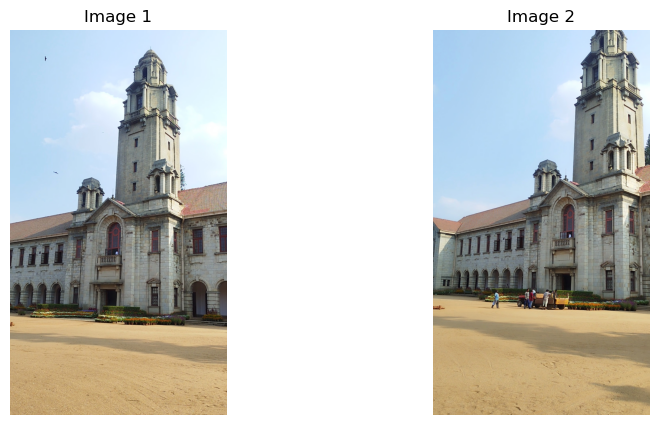


Pair 1
VID_20260224_155739_4.jpg ↔ VID_20260224_155831_2.jpg
Overlap: 3793.0
Baseline: 0.843
Angle: 5.65
Score: 0.639


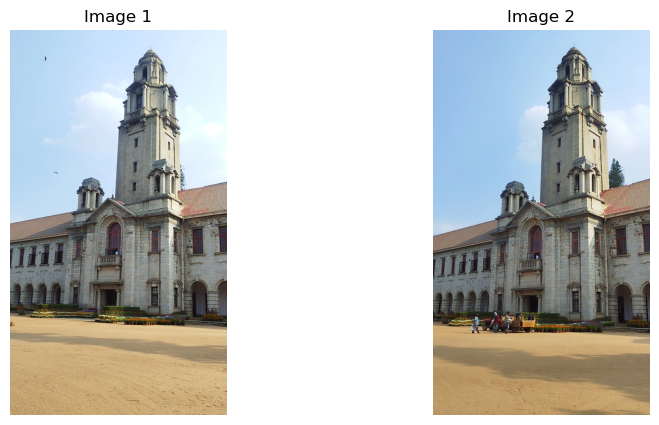


Pair 2
VID_20260224_155739_5.jpg ↔ VID_20260224_155831_2.jpg
Overlap: 3219.0
Baseline: 0.841
Angle: 13.76
Score: 0.631


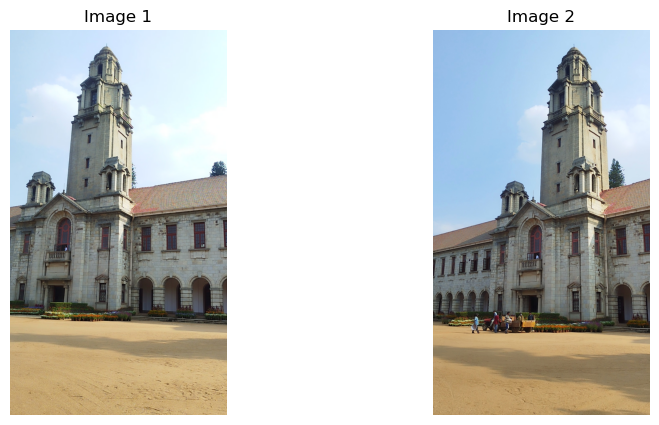


Pair 3
IMG_20260224_154558.jpg ↔ IMG_20260224_154700.jpg
Overlap: 3703.0
Baseline: 0.609
Angle: 6.27
Score: 0.628


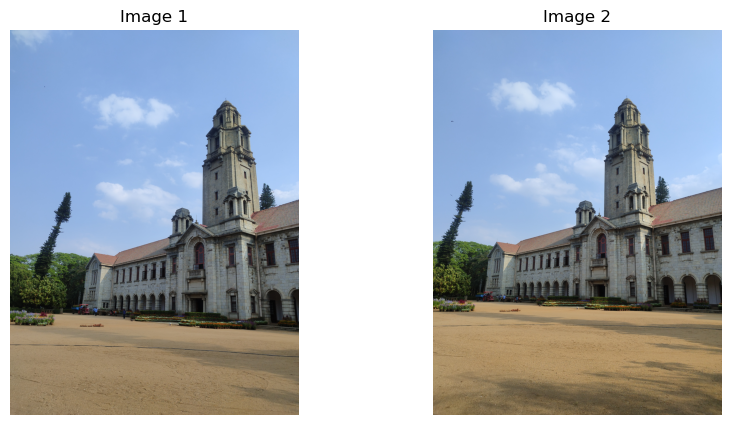


Pair 4
VID_20260224_155739_5.jpg ↔ VID_20260224_155831_3.jpg
Overlap: 3405.0
Baseline: 0.841
Angle: 8.87
Score: 0.623


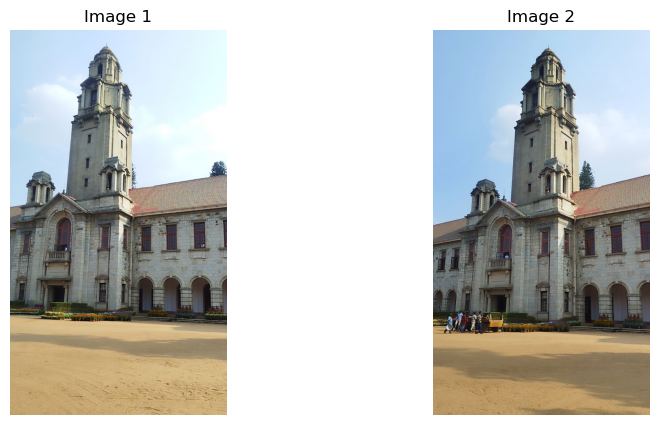


Pair 5
VID_20260224_155739_3.jpg ↔ VID_20260224_155831_1.jpg
Overlap: 3770.0
Baseline: 0.843
Angle: 4.37
Score: 0.620


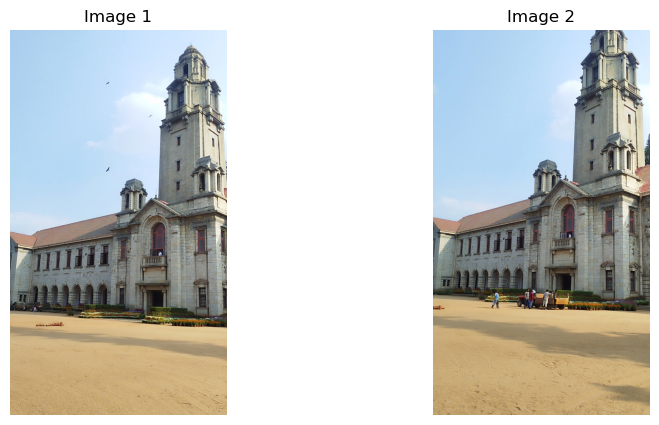

In [47]:
visualize_best_pairs(df_best, df, image_folder)

In [48]:
df_best.to_csv("../best_image_pairs2.csv", index=False)

## Get Degenerate Pairs

In [23]:
def parse_array(arr_str, shape):
    # arr = np.fromstring(arr_str.strip("[]"), sep=' ')
    return arr_str.reshape(shape)

def compute_relative_pose(row1, row2):
    R1 = parse_array(row1["R"], (3,3))
    R2 = parse_array(row2["R"], (3,3))

    C1 = parse_array(row1["C"], (3,))
    C2 = parse_array(row2["C"], (3,))

    # Relative rotation
    R_rel = R2 @ R1.T

    # Rotation angle
    trace = np.trace(R_rel)
    rot_angle = np.degrees(np.arccos(np.clip((trace - 1)/2, -1, 1)))

    # Translation
    t = C2 - C1
    baseline = np.linalg.norm(t)

    return rot_angle, baseline, R_rel, t

In [3]:
def find_degenerate_pairs(df_images, top_k=3):

    pure_rotation = []
    pure_translation = []
    planar_candidates = []

    rows = df_images.to_dict("records")

    for i in range(len(rows)):
        for j in range(i+1, len(rows)):

            row1 = rows[i]
            row2 = rows[j]

            rot_angle, baseline, _, _ = compute_relative_pose(row1, row2)

            # --- Case A: Pure rotation ---
            if baseline < 0.05 and rot_angle > 10:
                pure_rotation.append((row1["image_id"], row2["image_id"], rot_angle, baseline))

            # --- Case B: Pure translation ---
            if baseline > 0.5 and rot_angle < 2:
                pure_translation.append((row1["image_id"], row2["image_id"], rot_angle, baseline))

    # Sort and pick best examples
    pure_rotation = sorted(pure_rotation, key=lambda x: x[3])[:top_k]
    pure_translation = sorted(pure_translation, key=lambda x: -x[3])[:top_k]

    return pure_rotation, pure_translation

In [26]:
import numpy as np

def parse_points3D(points3D_path):
    points3D_dict = {}

    with open(points3D_path, "r") as f:
        for line in f:
            if line.startswith("#") or line.strip() == "":
                continue

            parts = line.strip().split()

            point_id = int(parts[0])

            X = float(parts[1])
            Y = float(parts[2])
            Z = float(parts[3])

            points3D_dict[point_id] = np.array([X, Y, Z])

    return points3D_dict

def parse_visibility(points3D_path):
    visibility = {}

    with open(points3D_path, "r") as f:
        for line in f:
            if line.startswith("#") or line.strip() == "":
                continue

            parts = line.strip().split()
            point_id = int(parts[0])

            # Track starts from index 8
            track = parts[8:]

            for i in range(0, len(track), 2):
                img_id = int(track[i])

                if img_id not in visibility:
                    visibility[img_id] = set()

                visibility[img_id].add(point_id)

    return visibility

In [18]:
def is_planar(points3D, threshold=0.01):
    """
    Check if points lie on a plane using SVD
    """

    centroid = np.mean(points3D, axis=0)
    centered = points3D - centroid

    _, S, _ = np.linalg.svd(centered)

    # Smallest singular value → planarity
    return S[-1] < threshold

In [28]:
def find_planar_pairs(df_images, visibility_dict, points3D_dict, top_k=3):

    planar_pairs = []

    image_ids = list(visibility_dict.keys())

    for i in range(len(image_ids)):
        for j in range(i+1, len(image_ids)):

            id1 = image_ids[i]
            id2 = image_ids[j]

            common_pts = visibility_dict[id1].intersection(visibility_dict[id2])

            if len(common_pts) < 50:
                continue

            pts = np.array([points3D_dict[pid] for pid in common_pts])

            if is_planar(pts):
                planar_pairs.append((id1, id2, len(common_pts)))

    return planar_pairs[:top_k]

In [29]:
points3D_path =  f"{base_path}/points3D.txt"

points3D_dict = parse_points3D(points3D_path)
visibility_dict = parse_visibility(points3D_path)

print("Total 3D points:", len(points3D_dict))
print("Total images with visibility:", len(visibility_dict))

pure_rot, pure_trans = find_degenerate_pairs(df_images)

planar_pairs = find_planar_pairs(df_images, visibility_dict, points3D_dict)

print("Pure Rotation:", pure_rot)
print("Pure Translation:", pure_trans)
print("Planar Cases:", planar_pairs)

Total 3D points: 97027
Total images with visibility: 222
Pure Rotation: [(85, 88, 92.6884251101627, 0.0029211553570570752), (166, 169, 23.969604566092265, 0.002969415559389206), (166, 168, 17.00184787809664, 0.003566930392264007)]
Pure Translation: [(72, 107, 1.6780421743822085, 8.891960544359803), (30, 105, 1.913347886562432, 7.761427664051329), (104, 214, 1.9867930730040788, 7.660982660018193)]
Planar Cases: []


In [30]:
df_best

,img1_id,img2_id,overlap,baseline,angle,score
0,225,231,3434,0.839300,11.213439,0.647580
1,225,232,3793,0.843088,5.652869,0.638692
2,226,232,3219,0.840993,13.759098,0.631209
3,99,105,3703,0.608581,6.266322,0.627549
4,226,233,3405,0.840751,8.872413,0.623349
5,224,231,3770,0.842938,4.371209,0.620089


In [31]:
def compute_overlap(id1, id2, visibility_dict):
    if id1 not in visibility_dict or id2 not in visibility_dict:
        return 0
    return len(visibility_dict[id1].intersection(visibility_dict[id2]))

In [65]:
def append_degenerate_pairs(
    df_best,
    df_images,
    visibility_dict,
    min_overlap=300,              # NEW: enforce sufficient matches
    baseline_thresh_rot=0.05,
    angle_thresh_rot=25,
    baseline_thresh_trans_low=1.0,   # lower bound
    baseline_thresh_trans_high=3.0,  # avoid extreme far pairs
    angle_thresh_trans=5,            # relaxed (not too strict)
    top_k=45
):

    rows = df_images.to_dict("records")

    pure_rotation = []
    pure_translation = []

    for i in range(len(rows)):
        for j in range(i+1, len(rows)):

            row1 = rows[i]
            row2 = rows[j]

            id1 = row1["image_id"]
            id2 = row2["image_id"]

            # --- Compute overlap FIRST ---
            overlap = compute_overlap(id1, id2, visibility_dict)

            # 🚨 Skip low-overlap pairs
            if overlap < min_overlap:
                continue

            rot_angle, baseline, _, _ = compute_relative_pose(row1, row2)

            # --- PURE ROTATION (small baseline, noticeable rotation) ---
            if (
                baseline < baseline_thresh_rot and
                rot_angle > angle_thresh_rot
            ):
                pure_rotation.append({
                    "img1_id": id1,
                    "img2_id": id2,
                    "overlap": overlap,
                    "baseline": baseline,
                    "angle": rot_angle,
                    "score": np.nan
                })

            # --- PURE TRANSLATION (moderate baseline, low rotation) ---
            if (
                baseline_thresh_trans_low < baseline < baseline_thresh_trans_high and
                rot_angle < angle_thresh_trans
            ):
                pure_translation.append({
                    "img1_id": id1,
                    "img2_id": id2,
                    "overlap": overlap,
                    "baseline": baseline,
                    "angle": rot_angle,
                    "score": np.nan
                })

    # --- Sort smarter (not extreme, but meaningful) ---

    # Rotation: smallest baseline but still enough rotation
    pure_rotation = sorted(
        pure_rotation,
        key=lambda x: (x["baseline"], -x["angle"])
    )[:top_k]

    # Translation: moderate baseline, low rotation, high overlap
    pure_translation = sorted(
        pure_translation,
        key=lambda x: (-x["overlap"], x["angle"])
    )[:top_k]

    # --- Convert to DataFrame ---
    df_rot = pd.DataFrame(pure_rotation)
    df_trans = pd.DataFrame(pure_translation)

    # --- Append ---
    df_combined = pd.concat([df_best, df_rot, df_trans], ignore_index=True)

    return df_combined

In [66]:
df_best_updated = append_degenerate_pairs(
    df_best,
    df_images,
    visibility_dict
)

print(df_best_updated)

    img1_id  img2_id  overlap  baseline      angle     score
0       225      231     3434  0.839300  11.213439  0.647580
1       225      232     3793  0.843088   5.652869  0.638692
2       226      232     3219  0.840993  13.759098  0.631209
3        99      105     3703  0.608581   6.266322  0.627549
4       226      233     3405  0.840751   8.872413  0.623349
..      ...      ...      ...       ...        ...       ...
91        5       46      580  2.454895   4.688163       NaN
92      168      214      566  2.002159   2.536364       NaN
93        4      169      555  2.625123   4.538840       NaN
94        6      171      550  2.591913   4.943398       NaN
95       37      170      526  2.650191   4.623811       NaN

[96 rows x 6 columns]


In [67]:
df_sorted_baseline = df_best_updated.sort_values(by = "baseline", ascending = False)
df_sorted_baseline.head(10)

,img1_id,img2_id,overlap,baseline,angle,score
78,33,43,882,2.979933,2.440201,NaN
67,31,44,1147,2.956589,2.963042,NaN
66,92,98,1329,2.769004,3.841747,NaN
84,40,116,766,2.736600,2.804507,NaN
95,37,170,526,2.650191,4.623811,NaN
80,40,154,842,2.640187,4.405754,NaN
73,12,158,1012,2.632447,2.994719,NaN
93,4,169,555,2.625123,4.538840,NaN
76,37,43,924,2.620871,4.223965,NaN
87,4,168,659,2.620057,3.517759,NaN


In [68]:
df_best_updated[df_best_updated["baseline"] >= 1].sort_values(by = "overlap", ascending = False)[:10]

,img1_id,img2_id,overlap,baseline,angle,score
51,95,224,2329,1.428614,4.884135,NaN
52,95,225,2225,1.443199,3.924084,NaN
53,33,37,1936,2.279524,3.789288,NaN
54,98,104,1929,1.178831,3.613970,NaN
55,95,232,1853,1.806992,3.261494,NaN
56,43,91,1825,1.502683,4.898444,NaN
57,108,234,1807,1.019300,3.076305,NaN
58,37,213,1774,1.019044,3.137379,NaN
59,96,233,1688,1.843439,4.914913,NaN
60,95,233,1626,1.808913,2.775850,NaN


In [63]:
df_best_updated.to_csv("../best_image_pairs3.csv", index=False)

In [69]:
def add_pure_rotation_cases(
    df_best,
    df_images,
    visibility_dict,
    min_rotation=10,     # degrees
    max_baseline=0.05,
    min_overlap=300,
    top_k=3
):

    rows = df_images.to_dict("records")
    selected = []

    for i in range(len(rows)):
        for j in range(i+1, len(rows)):

            row1 = rows[i]
            row2 = rows[j]

            id1 = row1["image_id"]
            id2 = row2["image_id"]

            overlap = compute_overlap(id1, id2, visibility_dict)
            if overlap < min_overlap:
                continue

            rot_angle, baseline, _, _ = compute_relative_pose(row1, row2)

            if rot_angle >= min_rotation and baseline <= max_baseline:
                selected.append({
                    "img1_id": id1,
                    "img2_id": id2,
                    "overlap": overlap,
                    "baseline": baseline,
                    "angle": rot_angle,
                    "score": np.nan,
                    "case_type": "pure_rotation"
                })

    # Sort: smallest baseline, highest rotation
    selected = sorted(selected, key=lambda x: (x["baseline"], -x["angle"]))[:top_k]

    df_new = pd.DataFrame(selected)

    return pd.concat([df_best, df_new], ignore_index=True)

In [70]:
def add_pure_translation_cases(
    df_best,
    df_images,
    visibility_dict,
    min_baseline=0.5,
    max_rotation=5,
    min_overlap=300,
    top_k=3
):

    rows = df_images.to_dict("records")
    selected = []

    for i in range(len(rows)):
        for j in range(i+1, len(rows)):

            row1 = rows[i]
            row2 = rows[j]

            id1 = row1["image_id"]
            id2 = row2["image_id"]

            overlap = compute_overlap(id1, id2, visibility_dict)
            if overlap < min_overlap:
                continue

            rot_angle, baseline, _, _ = compute_relative_pose(row1, row2)

            if baseline >= min_baseline and rot_angle <= max_rotation:
                selected.append({
                    "img1_id": id1,
                    "img2_id": id2,
                    "overlap": overlap,
                    "baseline": baseline,
                    "angle": rot_angle,
                    "score": np.nan,
                    "case_type": "pure_translation"
                })

    # Sort: highest overlap, lowest rotation
    selected = sorted(selected, key=lambda x: (-x["overlap"], x["angle"]))[:top_k]

    df_new = pd.DataFrame(selected)

    return pd.concat([df_best, df_new], ignore_index=True)

In [74]:
# Add rotation-degenerate cases
df_updated = add_pure_rotation_cases(
    df_best,
    df_images,
    visibility_dict,
    min_rotation=10,
    max_baseline=0.05,
    min_overlap=300,
    top_k=100
)

# Add translation-degenerate cases
df_updated = add_pure_translation_cases(
    df_updated,
    df_images,
    visibility_dict,
    min_baseline=1,
    max_rotation=5,
    min_overlap=300,
    top_k=100
)


In [80]:
df_updated[df_updated['case_type'] == "pure_translation"].sort_values(by = 'overlap', ascending = False)

,img1_id,img2_id,overlap,baseline,angle,score,case_type
106,95,224,2329,1.428614,4.884135,NaN,pure_translation
107,95,225,2225,1.443199,3.924084,NaN,pure_translation
108,33,37,1936,2.279524,3.789288,NaN,pure_translation
109,98,104,1929,1.178831,3.613970,NaN,pure_translation
110,95,232,1853,1.806992,3.261494,NaN,pure_translation
...,...,...,...,...,...,...,...
193,108,166,334,5.692614,4.686096,NaN,pure_translation
194,30,231,327,6.992881,3.056681,NaN,pure_translation
195,155,210,325,3.579666,4.155892,NaN,pure_translation
196,44,225,305,4.768227,4.043165,NaN,pure_translation


In [81]:
df_updated.to_csv("../best_image_pairs4.csv", index=False)
df_updated.shape

(198, 7)


Pair 0
VID_20260224_155739_4.jpg ↔ VID_20260224_155831_2.jpg
Overlap: 3793.0
Baseline: 0.843
Angle: 5.65
Score: 0.639
Saved visualization to: ../Report/pair_0.png


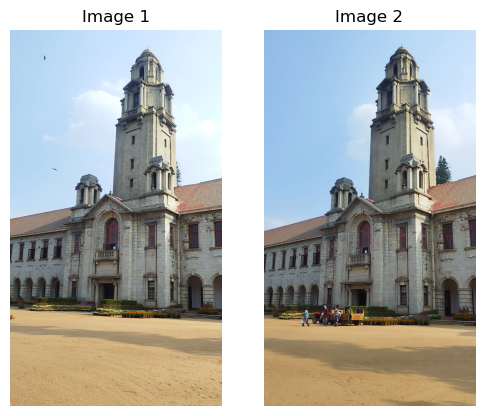


Pair 1
VID_20260224_155739_5.jpg ↔ VID_20260224_155831_2.jpg
Overlap: 3219.0
Baseline: 0.841
Angle: 13.76
Score: 0.631
Saved visualization to: ../Report/pair_1.png


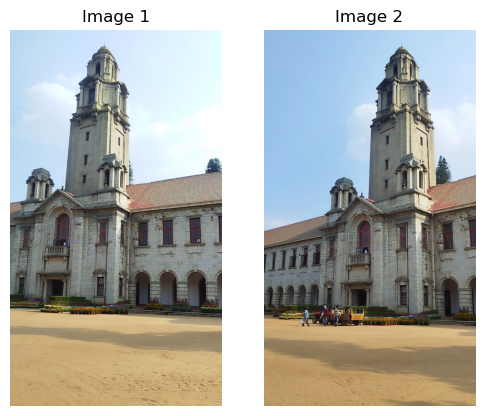


Pair 2
IMG_20260224_154548.jpg ↔ IMG_20260224_154550.jpg
Overlap: 2599.0
Baseline: 0.016
Angle: 26.53
Score: nan
Saved visualization to: ../Report/pair_2.png


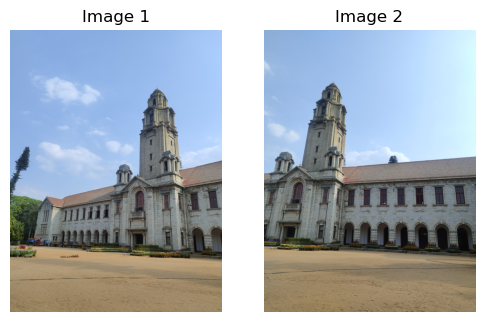


Pair 3
IMG_20260224_154829.jpg ↔ IMG_20260224_154836.jpg
Overlap: 1774.0
Baseline: 0.033
Angle: 35.76
Score: nan
Saved visualization to: ../Report/pair_3.png


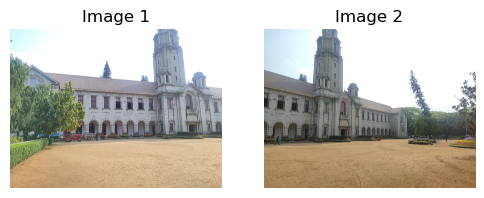


Pair 4
IMG_20260224_153537.jpg ↔ IMG_20260224_153546.jpg
Overlap: 1471.0
Baseline: 0.023
Angle: 33.39
Score: nan
Saved visualization to: ../Report/pair_4.png


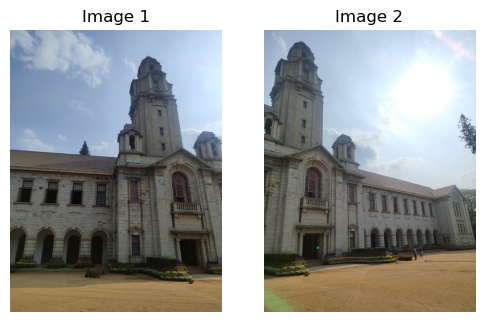


Pair 5
IMG_20260224_154522.jpg ↔ VID_20260224_155831_2.jpg
Overlap: 1853.0
Baseline: 1.807
Angle: 3.26
Score: nan
Saved visualization to: ../Report/pair_5.png


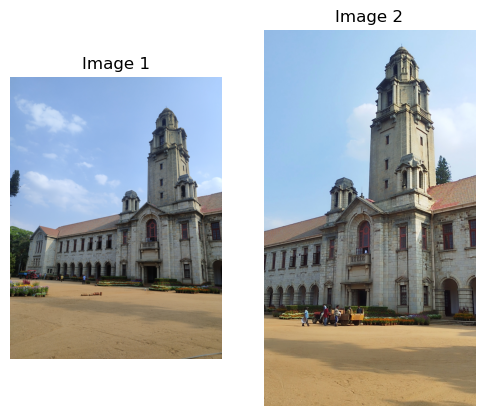


Pair 6
IMG_20260224_153803.jpg ↔ IMG_20260224_153832.jpg
Overlap: 1936.0
Baseline: 2.280
Angle: 3.79
Score: nan
Saved visualization to: ../Report/pair_6.png


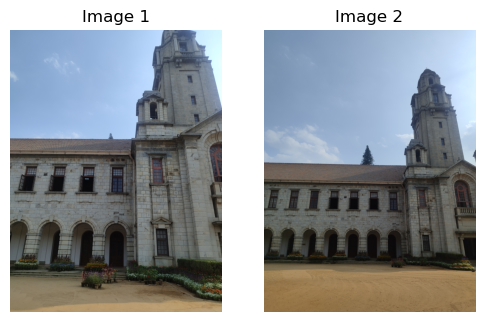

In [98]:
save_path = "../Report/"
df_analysis = pd.read_csv("../best_image_pairs_final.csv")
visualize_best_pairs(df_analysis, df, image_folder, save_path =  save_path)